In [38]:
import os
import sys
from pathlib import Path

# 현재 노트북 파일의 절대 경로를 찾는 안전한 방법
NOTEBOOK_PATH = Path(os.getcwd()).resolve()
print("NOTEBOOK PATH:", NOTEBOOK_PATH)

# 프로젝트 ROOT를 NOTEBOOK_PATH 기준으로 계산
# Multi-agent.ipynb 가 BioProtocol/agents/ 안에 있다고 가정
ROOT = NOTEBOOK_PATH.parents[0]  # = BioProtocol
print("PROJECT ROOT:", ROOT)

if str(ROOT) not in sys.path:
    sys.path.append(str(ROOT))

%load_ext autoreload
%autoreload 2


NOTEBOOK PATH: /Users/haeb/Workspaces/BioProtocol/agents
PROJECT ROOT: /Users/haeb/Workspaces/BioProtocol
The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [39]:
from dotenv import load_dotenv

load_dotenv()

import os

print("Loaded OPENAI_API_KEY exists:", "OPENAI_API_KEY" in os.environ)

Loaded OPENAI_API_KEY exists: True


# Task Planner

In [19]:
from agents.planner_state import PlannerState
from agents.task_planner_node import run_task_planner

state = PlannerState(
    protocol_id="Bio-protocol-2096",
    methods_text="...",  # gold_pairs_testset에서 Methods 텍스트 넣기
)

result = run_task_planner(state)
print(result)


protocol_id='Bio-protocol-2096' methods_text='...' rag_enabled=True max_tasks=12 tasks_planned=[Task(id='T1', title='Cell culture and treatment', description='Cultivate the appropriate cell lines under specified conditions and apply any treatments or interventions as outlined in the study protocol.', type='experiment'), Task(id='T2', title='Chromatin preparation and sonication', description='Isolate chromatin from the cultured cells and subject it to sonication to achieve the desired fragment size for downstream applications.', type='preparation'), Task(id='T3', title='Immunoprecipitation', description='Perform immunoprecipitation using specific antibodies to enrich for the target protein or chromatin modifications from the prepared samples.', type='experiment'), Task(id='T4', title='Library preparation for sequencing', description='Prepare sequencing libraries from the immunoprecipitated chromatin samples according to the specified protocol to enable subsequent analysis.', type='prepa

In [20]:
pairs_path = ROOT / "data/gold/gold_pairs_testset.jsonl"

examples = []
with pairs_path.open("r") as f:
    for line in f:
        line = line.strip()
        if not line:
            continue
        examples.append(json.loads(line))

len(examples), examples[0]["protocol_id"]


(46, 'Bio-protocol-2096')

In [21]:
example = examples[0]  # 첫 번째 프로토콜 테스트
protocol_id = example["protocol_id"]
methods_text = example.get("sec_text") or example.get("text") or ""

print("protocol_id:", protocol_id)
print(methods_text[:1000])  # 앞부분만 확인


protocol_id: Bio-protocol-2096
Methods
Cell culture, neuronal differentiation and cell transfection
Neural stem cells, Cor3–1 were grown in Complete media (DMEM/HAM’S-F12 (Sigma, D8437), 1.45% Glucose (Sigma,
G28644
), 1 × MEM-NEAA (Gibco, 11140-035), 100 units/ml penicillin and 100 μg/ml streptomycin (Gibco, 15140-122), 0.16% BSA (Gibco, 15260-037), 0.1 mM β-Mercapto-ethanol (Gibco 31350-010), 1% B-27 supplement (Gibco, 17504-044) and 0.5% N2 supplement (Gibco, 17502-048)). Before changing the medium or passaging the cells, 10 ng/ml mouse EGF (Peprotech, 315-09), 10 ng/ml human FGF (R&D systems, 233-FB) and 1 μg/ml Laminin (Sigma, L2020-1MG) were added to the required volume of Complete media. For neuronal differentiation, 24 hours after seeding, cells were transferred into a priming medium Euromed-N (Euroclone) supplemented with 1% B-27 without vitamin A (Gibco, 12587010), 0.5% N2 and 10 ng/ml human FGF for 3 days. Cells were then transferred into a differentiation medium (1:3 ratio 

In [22]:
planner_state = PlannerState(
    protocol_id=protocol_id,
    methods_text=methods_text,
    rag_enabled=False,  # 먼저 baseline만
    max_tasks=12,
)

planner_state = run_task_planner(planner_state, model="gpt-4o-mini")

print("=== Planned Tasks ===")
for t in planner_state.tasks_planned:
    print(f"{t.id}: {t.title}")
    print("  ", t.description)


=== Planned Tasks ===
T1: Cell culture and maintenance
   Grow neural stem cells (Cor3–1 and Floxed-Huwe1-RYFP) and P19 cells in appropriate media, ensuring proper conditions for proliferation and differentiation.
T2: Neuronal differentiation
   Induce neuronal differentiation of Cor3–1 and P19 cells by transferring them to specific differentiation media and adjusting growth factors over time.
T3: Cell transfection
   Transfect P19 cells with plasmids using Lipofectamine 2000 according to the manufacturer's instructions to study gene expression.
T4: RNA extraction and cDNA synthesis
   Extract total RNA from cultured cells using the RNeasy kit and synthesize cDNA using the QuantiTect Reverse Transcription Kit.
T5: Quantitative Real-Time PCR
   Perform qRT-PCR to quantify gene expression levels, using specific primers and normalizing against a housekeeping gene.
T6: Western blot analysis
   Conduct Western blotting to detect specific proteins in cell lysates, including preparation of sa

# Step Structurer

In [24]:
from agents.step_state import StepState
from agents.step_structurer_node import run_step_structurer


In [25]:
step_state = StepState(
    protocol_id=protocol_id,
    methods_text=methods_text,
    tasks_planned=planner_state.tasks_planned,
    max_steps_per_task=8,
)

step_state = run_step_structurer(step_state, model="gpt-4o-mini")

print("=== Structured Steps ===")
for s in step_state.steps_structured:
    print(f"{s.id} (Task {s.task_id}) [{s.step_type}] - {s.title}")
    print("  ", s.description)


=== Structured Steps ===
S1 (Task T1) [setup] - Prepare Complete Media
   Prepare Complete media by mixing DMEM/HAM’S-F12, glucose, MEM-NEAA, penicillin, streptomycin, BSA, β-Mercapto-ethanol, B-27, and N2 supplements.
S2 (Task T1) [procedure] - Culture Neural Stem Cells
   Seed Cor3–1 and Floxed-Huwe1-RYFP neural stem cells in Complete media and incubate under appropriate conditions for proliferation.
S3 (Task T1) [procedure] - Culture P19 Cells
   Seed P19 cells in MEM-α supplemented with FBS, penicillin, and streptomycin, and maintain under appropriate conditions.
S4 (Task T2) [experiment] - Induce Neuronal Differentiation
   Transfer Cor3–1 and P19 cells to priming medium supplemented with FGF for 3 days, followed by differentiation medium for an additional 3 days.
S5 (Task T2) [experiment] - Adjust Growth Factors
   Change differentiation medium every 3 days, reducing FGF concentration while maintaining BDNF concentration.
S6 (Task T3) [experiment] - Transfect P19 Cells
   Transfe

# Task Planner + Step Structurer

In [40]:
from typing import List, Optional, Dict
from pydantic import BaseModel

from agents.planner_state import Task
from agents.step_state import Step


class ProtocolPlanningState(BaseModel):
    protocol_id: str
    methods_text: str

    rag_enabled: bool = False
    max_tasks: int = 12
    max_steps_per_task: int = 8

    tasks_planned: List[Task] = []
    steps_structured: List[Step] = []

    planner_raw: Optional[Dict] = None
    step_raw: Optional[Dict] = None


In [41]:
# !pip install langgraph


In [42]:
def planner_node(state: ProtocolPlanningState) -> ProtocolPlanningState:
    p_state = PlannerState(
        protocol_id=state.protocol_id,
        methods_text=state.methods_text,
        rag_enabled=state.rag_enabled,
        max_tasks=state.max_tasks,
    )
    p_state = run_task_planner(p_state, model="gpt-4o-mini")

    state.tasks_planned = p_state.tasks_planned
    state.planner_raw = p_state.planner_raw
    return state


def step_node(state: ProtocolPlanningState) -> ProtocolPlanningState:
    s_state = StepState(
        protocol_id=state.protocol_id,
        methods_text=state.methods_text,
        tasks_planned=state.tasks_planned,
        max_steps_per_task=state.max_steps_per_task,
    )
    s_state = run_step_structurer(s_state, model="gpt-4o-mini")

    state.steps_structured = s_state.steps_structured
    state.step_raw = s_state.step_raw
    return state


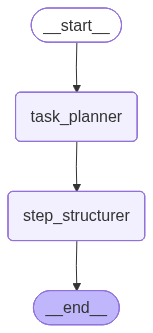

In [43]:
def build_protocol_planning_graph():
    graph = StateGraph(ProtocolPlanningState)

    graph.add_node("task_planner", planner_node)
    graph.add_node("step_structurer", step_node)

    graph.set_entry_point("task_planner")
    graph.add_edge("task_planner", "step_structurer")
    graph.add_edge("step_structurer", END)

    app = graph.compile()
    return app


graph_app = build_protocol_planning_graph()
graph_app


In [54]:
example = examples[0]  # 아까 썼던 gold pair 재사용
protocol_id = example["protocol_id"]
methods_text = example.get("sec_text") or example.get("text") or ""

init_state = ProtocolPlanningState(
    protocol_id=protocol_id,
    methods_text=methods_text,
    rag_enabled=False,
    max_tasks=12,
    max_steps_per_task=8,
)

final_state = graph_app.invoke(init_state)


In [55]:
print(type(final_state))

<class 'dict'>


In [35]:
print("=== Tasks ===")
tasks = final_state.get("tasks_planned", [])
for t in tasks:
    # t가 Task 객체일 수도, dict일 수도 있어서 둘 다 처리
    tid = t.id if hasattr(t, "id") else t.get("id")
    title = t.title if hasattr(t, "title") else t.get("title")
    desc = t.description if hasattr(t, "description") else t.get("description")
    ttype = t.type if hasattr(t, "type") else t.get("type")

    print(f"{tid}: {title} [{ttype}]")
    print("  ", desc)

print("\n=== Steps ===")
steps = final_state.get("steps_structured", [])
for s in steps:
    sid = getattr(s, "id", None) or s.get("id")
    task_id = getattr(s, "task_id", None) or s.get("task_id")
    step_type = getattr(s, "step_type", None) or s.get("step_type")
    title = getattr(s, "title", None) or s.get("title")
    desc = getattr(s, "description", None) or s.get("description")

    print(f"{sid} (Task {task_id}) [{step_type}] - {title}")
    print("  ", desc)


=== Tasks ===
T1: Cell Culture and Maintenance [preparation]
   Grow neural stem cells (Cor3-1 and P19) in appropriate media, ensuring proper conditions for proliferation and differentiation.
T2: Neuronal Differentiation [experiment]
   Transfer neural stem cells into differentiation media to promote neuronal differentiation, changing the media as specified.
T3: Cell Transfection [experiment]
   Transfect P19 cells with plasmids using Lipofectamine 2000 according to the manufacturer's instructions.
T4: RNA Extraction and cDNA Synthesis [preparation]
   Extract total RNA from cells and synthesize cDNA using specific kits for subsequent quantitative PCR analysis.
T5: Quantitative Real-Time PCR [analysis]
   Perform qRT-PCR to quantify gene expression levels, using specific primers and normalizing to a housekeeping gene.
T6: Western Blot Analysis [analysis]
   Conduct western blotting to analyze protein expression levels in cell lysates, including sample preparation and antibody probing.


# IR converter + Verifier

In [65]:
from typing import List, Optional, Dict, Any
from pydantic import BaseModel, Field

from agents.planner_state import Task
from agents.step_state import Step
from agents.ir_state import IRNode


class ProtocolPipelineState(BaseModel):
    protocol_id: str
    methods_text: str

    # Planner 설정
    rag_enabled: bool = False
    max_tasks: int = 12
    max_steps_per_task: int = 8

    # 1) Task Planner 결과
    tasks_planned: List[Task] = Field(default_factory=list)
    planner_raw: Optional[Dict[str, Any]] = None

    # 2) Step Structurer 결과
    steps_structured: List[Step] = Field(default_factory=list)
    step_raw: Optional[Dict[str, Any]] = None

    # 3) IR Converter 결과
    ir_nodes: List[IRNode] = Field(default_factory=list)
    ir_edges: List[List[str]] = Field(default_factory=list)
    param_table: List[Dict[str, Any]] = Field(default_factory=list)

    # 4) Verifier 결과
    param_verdicts: List[Dict[str, Any]] = Field(default_factory=list)


In [66]:
from agents.planner_state import PlannerState
from agents.task_planner_node import run_task_planner


def planner_node(state: ProtocolPipelineState) -> ProtocolPipelineState:
    p_state = PlannerState(
        protocol_id=state.protocol_id,
        methods_text=state.methods_text,
        rag_enabled=state.rag_enabled,
        max_tasks=state.max_tasks,
    )
    p_state = run_task_planner(p_state, model="gpt-4o-mini")

    state.tasks_planned = p_state.tasks_planned
    state.planner_raw = p_state.planner_raw
    return state


In [67]:
from agents.step_state import StepState
from agents.step_structurer_node import run_step_structurer


def step_node(state: ProtocolPipelineState) -> ProtocolPipelineState:
    s_state = StepState(
        protocol_id=state.protocol_id,
        methods_text=state.methods_text,
        tasks_planned=state.tasks_planned,
        max_steps_per_task=state.max_steps_per_task,
    )
    s_state = run_step_structurer(s_state, model="gpt-4o-mini")

    state.steps_structured = s_state.steps_structured
    state.step_raw = s_state.step_raw
    return state


In [68]:
from agents.ir_state import IRState
from agents.ir_converter_node import run_ir_converter


def ir_node(state: ProtocolPipelineState) -> ProtocolPipelineState:
    # Step → dict 로 변환 + 필드 정규화
    steps_structured_dicts = []
    for s in state.steps_structured:
        d = s.model_dump()
        d["step_id"] = d.pop("id")
        d["text"] = d.get("description", "")
        steps_structured_dicts.append(d)

    ir_state = IRState(
        protocol_id=state.protocol_id,
        methods_text=state.methods_text,
        steps_structured=steps_structured_dicts,
    )
    ir_state = run_ir_converter(ir_state)

    state.ir_nodes = ir_state.ir_nodes
    state.ir_edges = ir_state.ir_edges
    # Param은 Pydantic 모델이므로 dict로 풀어서 저장해두면 다운스트림에 편함
    state.param_table = [p.model_dump() for p in ir_state.param_table]
    return state


In [69]:
from agents.verifier_state import VerifierState
from agents.verifier_node import run_verifier


def verifier_node(state: ProtocolPipelineState) -> ProtocolPipelineState:
    v_state = VerifierState(
        protocol_id=state.protocol_id,
        methods_text=state.methods_text,
        param_table=state.param_table,
    )
    v_state = run_verifier(v_state)

    state.param_verdicts = v_state.param_verdicts
    return state


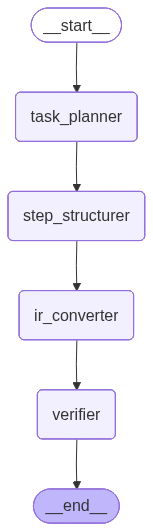

In [71]:
from langgraph.graph import StateGraph, END


def build_protocol_pipeline_graph():
    graph = StateGraph(ProtocolPipelineState)

    graph.add_node("task_planner", planner_node)
    graph.add_node("step_structurer", step_node)
    graph.add_node("ir_converter", ir_node)
    graph.add_node("verifier", verifier_node)

    graph.set_entry_point("task_planner")
    graph.add_edge("task_planner", "step_structurer")
    graph.add_edge("step_structurer", "ir_converter")
    graph.add_edge("ir_converter", "verifier")
    graph.add_edge("verifier", END)

    app = graph.compile()
    return app


graph_app = build_protocol_pipeline_graph()
graph_app

In [72]:
# 예: gold_pairs_testset.jsonl 을 이미 examples 리스트로 로드했다고 가정
example = examples[0]
protocol_id = example["protocol_id"]
methods_text = example.get("sec_text") or example.get("text") or ""

init_state = ProtocolPipelineState(
    protocol_id=protocol_id,
    methods_text=methods_text,
    rag_enabled=False,
    max_tasks=12,
    max_steps_per_task=8,
)

result_dict = graph_app.invoke(init_state)
# LangGraph는 dict를 돌려주므로 다시 모델로 복원
final_state = ProtocolPipelineState(**result_dict)


Error in verifier LLM call: Error code: 400 - {'error': {'message': "Invalid type for 'response_format': expected an object, but got a string instead.", 'type': 'invalid_request_error', 'param': 'response_format', 'code': 'invalid_type'}}
Error in verifier LLM call: Error code: 400 - {'error': {'message': "Invalid type for 'response_format': expected an object, but got a string instead.", 'type': 'invalid_request_error', 'param': 'response_format', 'code': 'invalid_type'}}
Error in verifier LLM call: Error code: 400 - {'error': {'message': "Invalid type for 'response_format': expected an object, but got a string instead.", 'type': 'invalid_request_error', 'param': 'response_format', 'code': 'invalid_type'}}
Error in verifier LLM call: Error code: 400 - {'error': {'message': "Invalid type for 'response_format': expected an object, but got a string instead.", 'type': 'invalid_request_error', 'param': 'response_format', 'code': 'invalid_type'}}
Error in verifier LLM call: Error code: 400 

In [73]:
from collections import Counter

print("protocol_id:", final_state.protocol_id)
print("#tasks:", len(final_state.tasks_planned))
print("#steps:", len(final_state.steps_structured))
print("#params:", len(final_state.param_table))

cnts = Counter(v["verdict"] for v in final_state.param_verdicts)
print("verdict breakdown:", dict(cnts))


protocol_id: Bio-protocol-2096
#tasks: 12
#steps: 20
#params: 10
verdict breakdown: {'ambiguous': 10}
